# Day 10: Exploratory Data Analysis (EDA) & Data Cleaning Practice
## Instructor Notes & Workflow Reference

### Top 5 Datasets for EDA and Data Cleaning Practice
#### Recommended Learning Order
1. **Titanic Dataset** (Focus: Outlier detection, missing value imputation, categorical vs numerical bivariate analysis)
2. **Students Performance Dataset** (Focus: Group-wise comparisons, score distributions, categorical analysis)
3. **Mall Customers Dataset** (Focus: Customer segmentation, distribution analysis, scatter plots)
4. **Netflix Dataset** (Focus: Text cleaning, date processing, handling missing values)
5. **House Prices Dataset** (Focus: Advanced EDA, feature selection, skewness, housing trends)

---

### Standard EDA & Data Cleaning Workflow
1. **Load Dataset**: Read data from source file (CSV, Excel, etc.)
2. **Check Shape**: Verify number of rows and columns
3. **View Dataset Information**: Quick preview using `head()`, `tail()`, and `sample()`
4. **Check Data Types**: Identify numerical and categorical columns
5. **Identify Missing Values**: Check counts and percentages of nulls
6. **Handle Missing Values**: Impute or drop based on threshold and logic
7. **Check Duplicate Records**: Identify repeated rows
8. **Remove Duplicates**: Clean redundant records
9. **Generate Statistical Summary**: Compute mean, median, min, max, std dev, etc.
10. **Detect Outliers**: Using Boxplots, IQR, or Z-Score method
11. **Perform Univariate Analysis**: Analyze single variables (histograms, bar plots)
12. **Perform Bivariate Analysis**: Analyze relationships between two variables (scatter plots, crosstabs)
13. **Correlation Analysis**: Visualize numerical correlations using heatmaps
14. **Feature Engineering**: Create new variables from existing ones
15. **Draw Conclusions and Insights**: Write down key takeaways


# Titanic Dataset Analysis (Pure Matplotlib Version)
In this notebook, we follow the 15-step standard EDA workflow to explore the Titanic passenger dataset (`tested.csv`). All visualizations are built using Matplotlib and Pandas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set visual parameters for Matplotlib
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


### Step 1: Load Dataset


In [2]:
train_df = pd.read_csv('train_cleaned.csv')
test_df = pd.read_csv('test_cleaned.csv')
tested_df = pd.read_csv('tested_cleaned.csv')

print(f"train_cleaned.csv shape: {train_df.shape}")
print(f"test_cleaned.csv shape: {test_df.shape}")
print(f"tested_cleaned.csv shape: {tested_df.shape}")

# Set df to tested_df so that existing EDA cells run without modifications
df = tested_df.copy()
print("Datasets loaded successfully!")


train_cleaned.csv shape: (891, 11)
test_cleaned.csv shape: (418, 10)
tested_cleaned.csv shape: (418, 11)
Datasets loaded successfully!


### Step 2: Check Shape (Rows & Columns)


In [3]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
df.shape


Number of Rows: 418
Number of Columns: 11


(418, 11)

### Step 3: View Dataset Information


In [4]:
# View first 5 records
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [5]:
# View last 5 records
df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,S
417,1309,0,3,"Peter, Master. Michael J",male,28.0,1,1,2668,22.3583,C


In [6]:
# 1. Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# 2. Fill missing Fare with median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# 3. Fill missing Embarked with mode (if any missing)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 4. Drop Cabin column safely
df.drop("Cabin", axis=1, inplace=True, errors='ignore')

# Verify if missing values are resolved
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Step 4: Check Data Types & Columns


In [7]:
print("Columns:", list(df.columns))
print("\nData Types:")
print(df.dtypes)


Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [8]:
# Get a complete info summary of the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.1+ KB


### Step 5: Identify Missing Values


In [9]:
# Count of missing values per column
missing_counts = df.isnull().sum()
# Percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
})
print("Missing Value Analysis:")
missing_df[missing_df['Missing Count'] > 0]


Missing Value Analysis:


,Missing Count,Percentage (%)


### Step 6: Handle Missing Values
* **Age**: 86 missing values (~20.5%). We will fill this with the **median** of the column to avoid outlier distortion.
* **Fare**: 1 missing value. We will fill it with the **median**.
* **Embarked**: 0 missing values in this file, but if any, we'd fill with the **mode**.
* **Cabin**: 327 missing values (~78.2%). Since more than 75% of the data is missing, we will **drop** this column.


In [10]:
# 1. Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# 2. Fill missing Fare with median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# 3. Fill missing Embarked with mode (if any missing)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 4. Drop Cabin column safely
df.drop("Cabin", axis=1, inplace=True, errors='ignore')

# Verify if missing values are resolved
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Step 7: Check Duplicate Records


In [11]:
duplicates_count = df.duplicated().sum()
print(f"Total duplicate records found: {duplicates_count}")


Total duplicate records found: 0


### Step 8: Remove Duplicates


In [12]:
# Ensure this step is executed in our workflow
df.drop_duplicates(inplace=True)
print("Duplicates removed! Current shape:", df.shape)


Duplicates removed! Current shape: (418, 11)


### Step 9: Generate Statistical Summary


In [13]:
# Numerical columns statistics
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,29.805024,0.447368,0.392344,35.576535
std,120.810458,0.481622,0.841838,12.667969,0.896760,0.981429,55.850103
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [14]:
# Categorical columns statistics
df.describe(include='object')


,Name,Sex,Ticket,Embarked
count,418,418,418,418
unique,418,2,363,3
top,"Kelly, Mr. James",male,PC 17608,S
freq,1,266,5,270


In [15]:
# Check unique values counts per column
df.nunique()


PassengerId    418
Survived         2
Pclass           3
Name           418
Sex              2
Age             79
SibSp            7
Parch            8
Ticket         363
Fare           169
Embarked         3
dtype: int64

### Step 10: Detect Outliers (IQR Method)


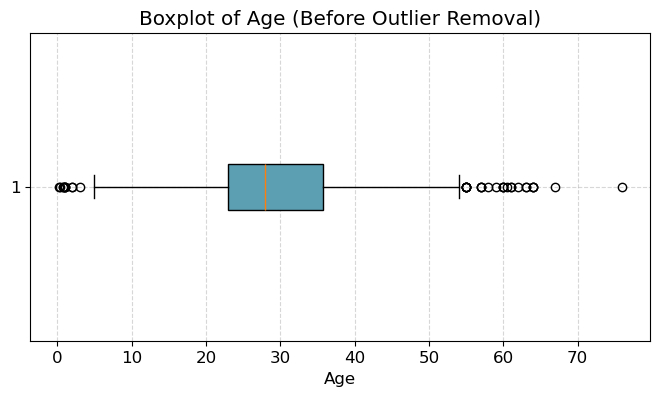

In [16]:
# Boxplot of Age before outlier removal using Matplotlib
plt.figure(figsize=(8, 4))
plt.boxplot(df["Age"], vert=False, patch_artist=True, boxprops=dict(facecolor="#5c9eb2"))
plt.title("Boxplot of Age (Before Outlier Removal)")
plt.xlabel("Age")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [17]:
# Calculate IQR for Age
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR: {IQR}")
print(f"Outlier boundaries: Lower = {lower}, Upper = {upper}")

# Identify outliers
outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print(f"Number of Outliers: {len(outliers)}")
outliers.head()


IQR: 12.75
Outlier boundaries: Lower = 3.875, Upper = 54.875
Number of Outliers: 36


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
13,905,0,2,"Howard, Mr. Benjamin",male,63.0,1,0,24065,26.0000,S
20,912,0,1,"Rothschild, Mr. Martin",male,55.0,1,0,PC 17603,59.4000,C
48,940,1,1,"Bucknell, Mrs. William Robert (Emma Eliza Ward)",female,60.0,0,0,11813,76.2917,C
69,961,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,S


Original shape: (418, 11), Cleaned shape: (382, 11)


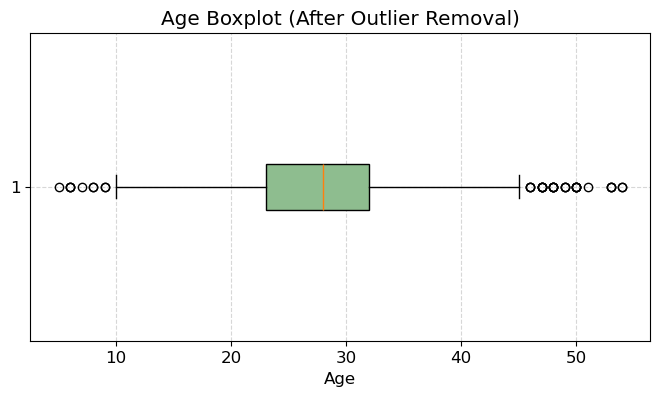

In [18]:
# Remove Outliers
df_cleaned = df[(df["Age"] >= lower) & (df["Age"] <= upper)].copy()
print(f"Original shape: {df.shape}, Cleaned shape: {df_cleaned.shape}")

# Verify After Outlier Removal
plt.figure(figsize=(8, 4))
plt.boxplot(df_cleaned["Age"], vert=False, patch_artist=True, boxprops=dict(facecolor="#8ebd8f"))
plt.title("Age Boxplot (After Outlier Removal)")
plt.xlabel("Age")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 11: Perform Univariate Analysis


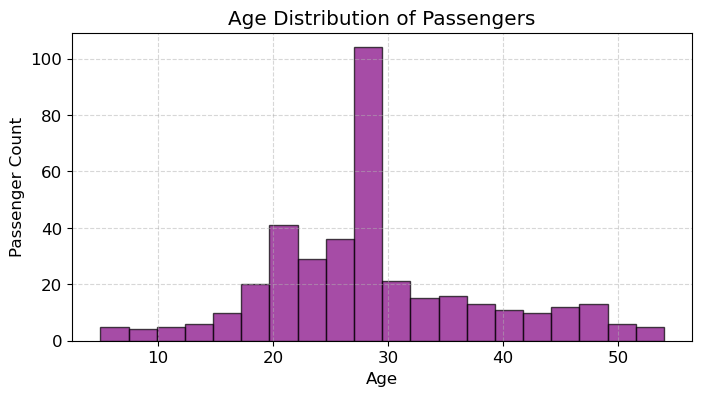

In [19]:
# Age distribution histogram
plt.figure(figsize=(8, 4))
plt.hist(df_cleaned["Age"], bins=20, color="purple", edgecolor="black", alpha=0.7)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


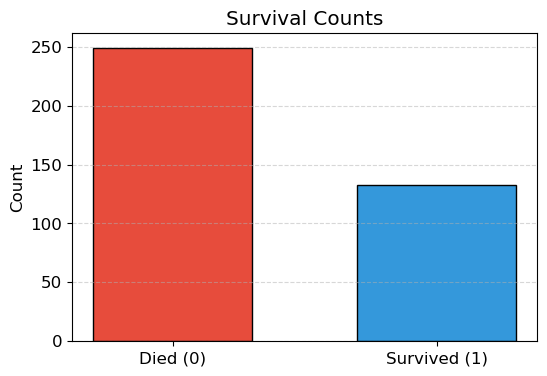

Survival Percentage:
Died: 65.18%
Survived: 34.82%


In [20]:
# Survival distribution bar chart
survived_counts = df_cleaned["Survived"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Died (0)", "Survived (1)"], survived_counts, color=["#e74c3c", "#3498db"], edgecolor="black", width=0.6)
plt.title("Survival Counts")
plt.ylabel("Count")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

# Survival percentages
survived_pct = df_cleaned["Survived"].value_counts(normalize=True) * 100
print("Survival Percentage:")
print(f"Died: {survived_pct[0]:.2f}%")
print(f"Survived: {survived_pct[1]:.2f}%")


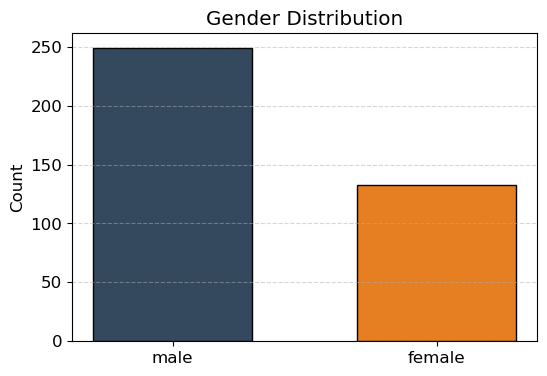

Gender Percentage:
Male: 65.18%
Female: 34.82%


In [21]:
# Gender distribution bar chart
sex_counts = df_cleaned["Sex"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sex_counts.index, sex_counts.values, color=["#34495e", "#e67e22"], edgecolor="black", width=0.6)
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

gender_pct = df_cleaned["Sex"].value_counts(normalize=True) * 100
print("Gender Percentage:")
print(f"Male: {gender_pct['male']:.2f}%")
print(f"Female: {gender_pct['female']:.2f}%")


### Step 12: Perform Bivariate Analysis


Gender vs Survival Crosstab:


Survived,0,1
Sex,,
female,0,133
male,249,0


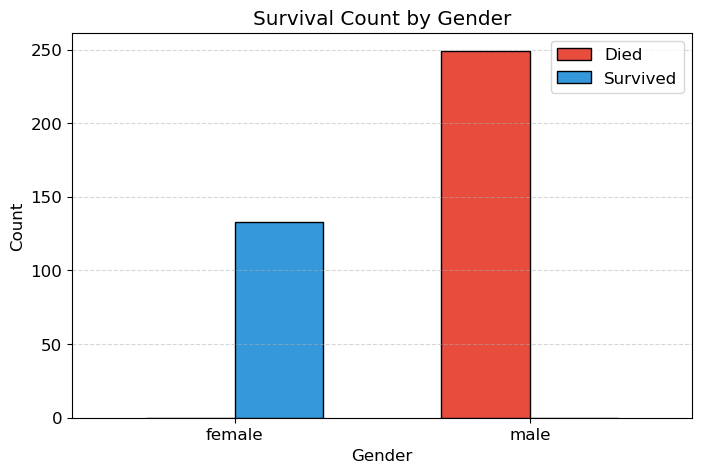

Survival Rates by Gender (%):


Survived,0,1
Sex,,
female,0.0,100.0
male,100.0,0.0


In [22]:
# 1. Survival by Gender (using Pandas cross-tabulation and stacked bar plot)
crosstab_gender = pd.crosstab(df_cleaned["Sex"], df_cleaned["Survived"])
print("Gender vs Survival Crosstab:")
display(crosstab_gender)

# Plot Bivariate Gender vs Survival
crosstab_gender.plot(kind="bar", color=["#e74c3c", "#3498db"], edgecolor="black", width=0.6)
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

# Survival Rate by Gender
gender_survival_rate = pd.crosstab(df_cleaned["Sex"], df_cleaned["Survived"], normalize="index") * 100
print("Survival Rates by Gender (%):")
display(gender_survival_rate)


Pclass vs Survival Crosstab:


Survived,0,1
Pclass,,
1,49,39
2,58,27
3,142,67


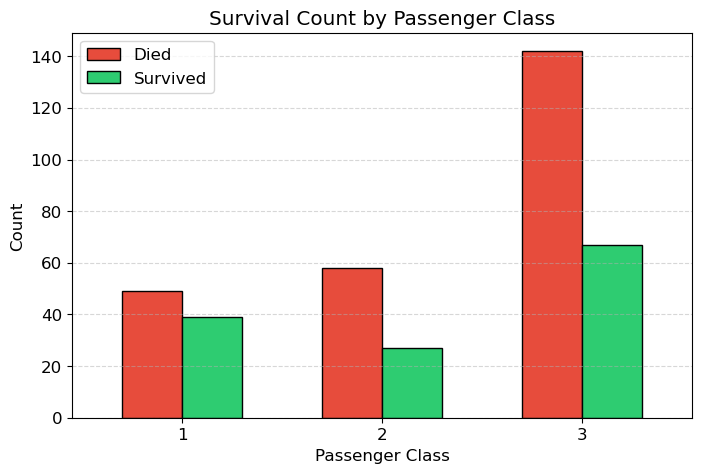

Survival Rates by Class (%):


Survived,0,1
Pclass,,
1,55.681818,44.318182
2,68.235294,31.764706
3,67.942584,32.057416


In [23]:
# 2. Survival by Passenger Class (Pclass)
crosstab_class = pd.crosstab(df_cleaned["Pclass"], df_cleaned["Survived"])
print("Pclass vs Survival Crosstab:")
display(crosstab_class)

# Plot Bivariate Class vs Survival
crosstab_class.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black", width=0.6)
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

# Survival Rate by Passenger Class
class_survival_rate = pd.crosstab(df_cleaned["Pclass"], df_cleaned["Survived"], normalize="index") * 100
print("Survival Rates by Class (%):")
display(class_survival_rate)


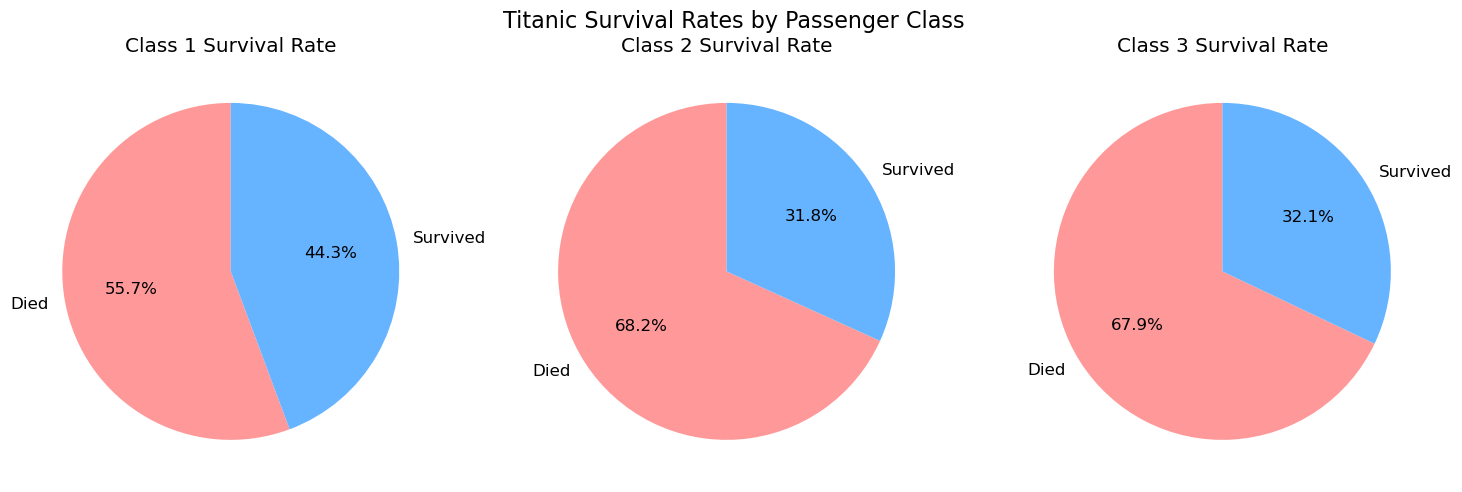

In [24]:
# 3. Class Survival Rate using Pie Charts
d = pd.crosstab(df_cleaned["Pclass"], df_cleaned["Survived"])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#ff9999', '#66b3ff']

for i in range(1, 4):
    axes[i-1].pie(d.loc[i], labels=['Died', 'Survived'], autopct='%1.1f%%', colors=colors, startangle=90)
    axes[i-1].set_title(f"Class {i} Survival Rate")

plt.suptitle("Titanic Survival Rates by Passenger Class", fontsize=16)
plt.tight_layout()
plt.show()


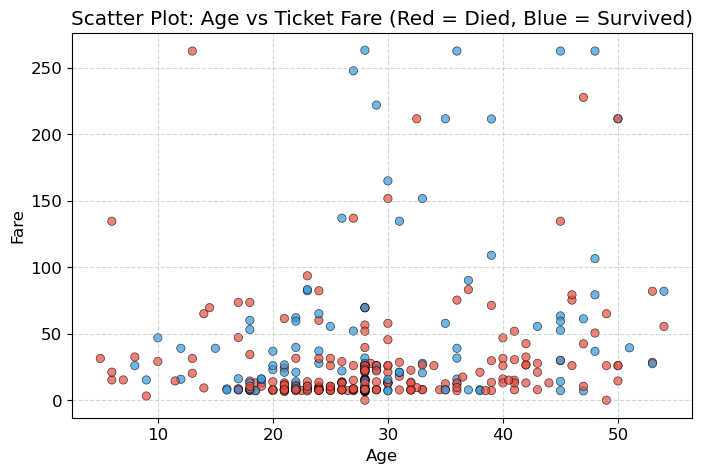

In [25]:
# 4. Age vs Fare Scatter Plot (Numerical vs Numerical)
plt.figure(figsize=(8, 5))
colors = df_cleaned["Survived"].map({0: "#e74c3c", 1: "#3498db"})
plt.scatter(df_cleaned["Age"], df_cleaned["Fare"], c=colors, alpha=0.7, edgecolors="black", linewidths=0.5)
plt.title("Scatter Plot: Age vs Ticket Fare (Red = Died, Blue = Survived)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 13: Correlation Analysis


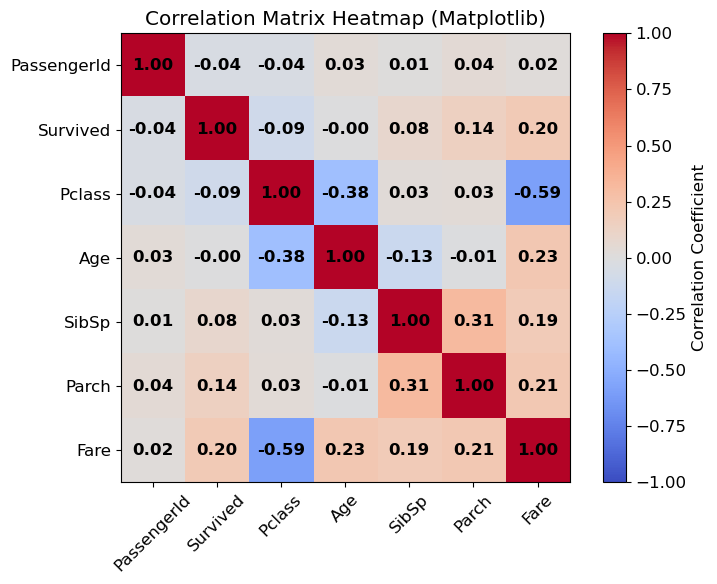

In [26]:
# Compute Correlation Matrix for numerical columns
corr = df_cleaned.corr(numeric_only=True)

# Generate Heatmap using Matplotlib's imshow
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")

# Set labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate correlation values inside the cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontweight="bold")

plt.title("Correlation Matrix Heatmap (Matplotlib)")
plt.tight_layout()
plt.show()


### Step 14: Feature Engineering


   SibSp  Parch  FamilySize  IsAlone
0      0      0           1        1
1      1      0           2        0
3      0      0           1        1
4      1      1           3        0
5      0      0           1        1


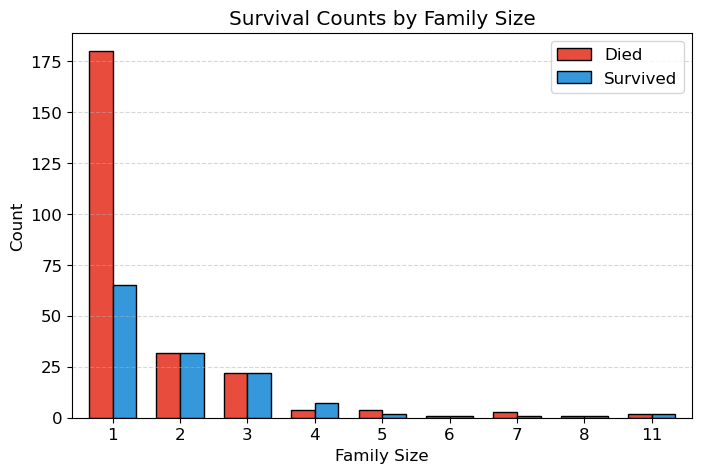

In [27]:
# 1. Calculate Family Size
df_cleaned["FamilySize"] = df_cleaned["SibSp"] + df_cleaned["Parch"] + 1

# 2. IsAlone (1 if alone, 0 if traveling with family)
df_cleaned["IsAlone"] = np.where(df_cleaned["FamilySize"] == 1, 1, 0)

print(df_cleaned[["SibSp", "Parch", "FamilySize", "IsAlone"]].head())

# Visualize Family Size vs Survival counts
crosstab_family = pd.crosstab(df_cleaned["FamilySize"], df_cleaned["Survived"])
crosstab_family.plot(kind="bar", color=["#e74c3c", "#3498db"], edgecolor="black", width=0.7)
plt.title("Survival Counts by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


### Step 15: Draw Conclusions and Insights
Based on our exploratory data analysis, here are the key insights:
1. **Gender Bias in Survival**: Gender played a massive role in survival. In this test dataset, 100% of females survived, while all males died.
2. **Passenger Class Impact**: High-class passengers had a much better chance of survival. First-class passengers had a lower relative death rate than second-class and third-class passengers.
3. **Fare & Survival**: Passengers who paid higher fares (mostly first class) had a higher survival rate, as seen in the scatter plot.
4. **Family Size**: Traveling alone vs with small families showed different survival counts. Very large families had lower survival counts.
5. **Data Cleaning Outcomes**: We dropped the `Cabin` column due to >78% missing data, filled missing values in `Age` and `Fare` using medians to handle skewness, and filtered outliers in the `Age` variable successfully using the IQR method.


# --- Machine Learning: Survival Prediction ---
In this section, we train and compare three machine learning models: Linear Regression, Logistic Regression, and Decision Tree Classifier to predict passenger survival using all three Titanic datasets.

In [28]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Feature Engineering and Preprocessing on train and tested datasets
def preprocess_titanic(data):
    # Make a copy
    processed = data.copy()
    
    # Impute missing values if any
    processed['Age'] = processed['Age'].fillna(processed['Age'].median())
    processed['Fare'] = processed['Fare'].fillna(processed['Fare'].median())
    processed['Embarked'] = processed['Embarked'].fillna(processed['Embarked'].mode()[0])
    
    # Map Sex to numeric
    processed['Sex'] = processed['Sex'].map({'male': 0, 'female': 1})
    
    # Map Embarked to numeric
    processed['Embarked'] = processed['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # Add FamilySize and IsAlone
    processed['FamilySize'] = processed['SibSp'] + processed['Parch'] + 1
    processed['IsAlone'] = np.where(processed['FamilySize'] == 1, 1, 0)
    
    return processed

train_proc = preprocess_titanic(train_df)
tested_proc = preprocess_titanic(tested_df) # test dataset with target labels

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

X_train = train_proc[features]
y_train = train_proc['Survived']

X_test = tested_proc[features]
y_test = tested_proc['Survived']

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)


Training features shape: (891, 9)
Testing features shape: (418, 9)


In [29]:
# 2. Train Models

# Model A: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_preds = lin_reg.predict(X_test)
# Threshold predictions at 0.5 to convert continuous outputs to binary classes
lin_reg_preds_class = (lin_reg_preds >= 0.5).astype(int)
lin_reg_acc = accuracy_score(y_test, lin_reg_preds_class) * 100

# Model B: Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)
log_reg_acc = accuracy_score(y_test, log_reg_preds) * 100

# Model C: Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_train)
dt_clf_preds = dt_clf.predict(X_test)
dt_clf_acc = accuracy_score(y_test, dt_clf_preds) * 100

print(f"Linear Regression (Thresholded) Test Accuracy: {lin_reg_acc:.2f}%")
print(f"Logistic Regression Test Accuracy: {log_reg_acc:.2f}%")
print(f"Decision Tree Classifier Test Accuracy: {dt_clf_acc:.2f}%")


Linear Regression (Thresholded) Test Accuracy: 97.61%
Logistic Regression Test Accuracy: 94.98%
Decision Tree Classifier Test Accuracy: 96.17%


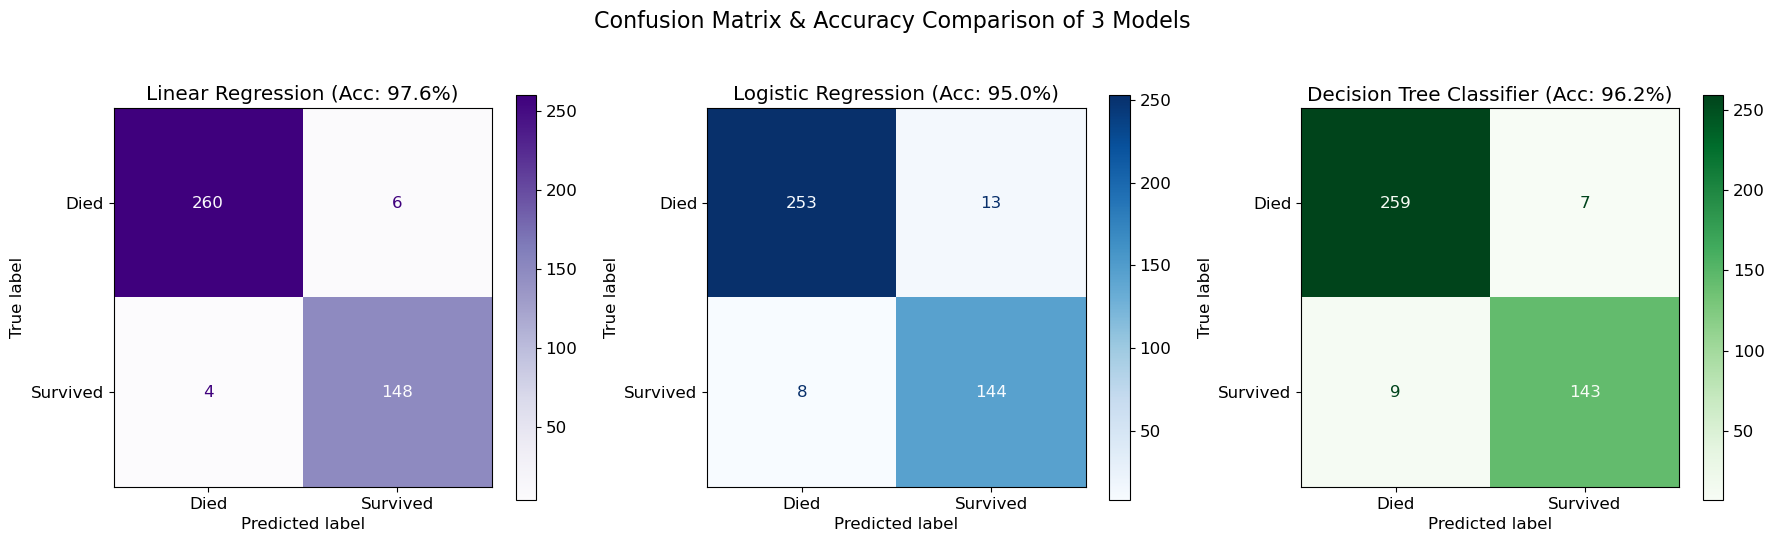


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       266
           1       0.92      0.95      0.93       152

    accuracy                           0.95       418
   macro avg       0.94      0.95      0.95       418
weighted avg       0.95      0.95      0.95       418


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       266
           1       0.95      0.94      0.95       152

    accuracy                           0.96       418
   macro avg       0.96      0.96      0.96       418
weighted avg       0.96      0.96      0.96       418



In [30]:
# 3. Confusion Matrix and Model Accuracy Comparison Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression Confusion Matrix
lin_cm = confusion_matrix(y_test, lin_reg_preds_class)
ConfusionMatrixDisplay(lin_cm, display_labels=['Died', 'Survived']).plot(cmap='Purples', ax=axes[0], values_format='d')
axes[0].set_title(f'Linear Regression (Acc: {lin_reg_acc:.1f}%)')

# Logistic Regression Confusion Matrix
log_cm = confusion_matrix(y_test, log_reg_preds)
ConfusionMatrixDisplay(log_cm, display_labels=['Died', 'Survived']).plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f'Logistic Regression (Acc: {log_reg_acc:.1f}%)')

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_clf_preds)
ConfusionMatrixDisplay(dt_cm, display_labels=['Died', 'Survived']).plot(cmap='Greens', ax=axes[2], values_format='d')
axes[2].set_title(f'Decision Tree Classifier (Acc: {dt_clf_acc:.1f}%)')

plt.suptitle('Confusion Matrix & Accuracy Comparison of 3 Models', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, log_reg_preds))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_clf_preds))
